# Predicting Top-Quartile Video Game Success from Pre-Release Metadata

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [ X ] YES - make available, Yidong Li, Yifei Liu, Xintong Liu, Yanbing Yao, Sihan Wang
* [   ] NO - keep private

## Link to video

https://drive.google.com/file/d/1nQATzlBTNCKjsiVkZP0-5Dq5FzzV1vO3/view?usp=drive_link

## Abstract

Video game sales are difficult to compare across years because the size and structure of the market change over time. To address this issue, we study relative commercial success rather than absolute sales and ask whether pre-release metadata can predict whether a game will rank in the top 25% of global sales within its release year. Using a video game sales dataset containing release year, platform, genre, publisher, and global sales, we construct a year-normalized binary outcome indicating whether each title belongs to the top quartile of sales in its release-year cohort.

We use release year, platform, genre, and publisher as predictors and compare a logistic regression model, a random forest classifier, and a CatBoost classifier. To make the evaluation more realistic, we train on games released from 1995 to 2014 and test on games released in 2015 and 2016, after excluding extremely sparse tail years. Our results show that pre-release metadata contain meaningful predictive signal. Logistic regression achieved an accuracy of 0.8002, an F1 score of 0.5821, and an ROC-AUC of 0.8320, random forest achieved an accuracy of 0.8075 and higher precision (0.6556) but lower recall and F1, and CatBoost achieved the strongest overall performance with an accuracy of 0.8138, an F1 score of 0.6079, and an ROC-AUC of 0.8484.

Overall, our findings suggest that simple pre-release structural metadata can partially identify commercially strong games, but relative sales success is still influenced by many unobserved factors, such as marketing intensity, franchise strength, pricing, and post-release reception. The models are therefore best viewed as coarse early-stage screening tools rather than complete explanations of video game success.

## Authors


Team list and credits:
- Xintong Liu: Background research, Visualization, Experimental investigation, Writing - review & editing, Video
- Yanbing Yao: Background research, data set description, Writing – annotations, Video
- Sihan Wang: Ethics, Team expectations, Writing – section titles and structure, Video
- Yifei Liu: Hypothesis, Project Timeline Proposal, data set description, Visualization
- Yidong Li: Research Qustion, Data Overview, Data Wrangling, EDA, Data Modeling and Assessment, Visualization, Writing, Discussion and Conclusion

## Research Question

Can pre-release metadata predict whether a video game will rank in the top 25% of global sales within its release year?

We focus on relative commercial success rather than absolute sales because raw sales figures are not directly comparable across time. Video game markets differ substantially by year in size, platform environment, and overall industry maturity. For that reason, we define success in year-normalized terms and ask whether features that are available before release, specifically release year, platform, genre, and publisher, can identify games that will perform unusually well relative to other games released in the same year.

## Background and Prior Work

Video game sales are a central indicator of commercial success, yet absolute sales figures are difficult to compare across years due to changes in market size and industry growth. To address this challenge, we study whether games can be identified as top performers based on their year-specific sales percentiles using information available prior to release.

Early empirical work on video game sales determinants provides important context for future prediction. A regression analysis by Fukuda (2017) examining factors that impact video game sales identifies key metrics such as platform, genre and review scores, which are significant predictors in explaining variation in global sales. Although the study focuses on explanatory relationships rather than prediction accuracy, it proves that systematic structure exists in game metadata and related signals, justifying the use of such characteristics for predictive models. <sup>[1](#ref1)</sup> It also highlights the challenge of working with noisy outcomes and complex interactions among various predictors, and reinforces the need for classification frameworks like yearly percentile rather than exact sales estimation.

Building on evidence that game characteristics are systematically associated with sales, more recent work explores whether these relationships can be harnessed for predictive purposes. Li et al. (2021) provides direct methodological support for our study by demonstrating that video game sales outcomes can be effectively predicted using only information available prior to release. Their findings show that pre-release metadata and machine learning methods can be used to predict sales, indicating that a pre-release prediction framework is feasible. As stated in their paper, "predicting sales of the video game can pre-adjust sales strategies and development plans in advance" <sup>[2](#ref2)</sup>, highlighting the practical value of pre-release sales prediction. The evidence directly supports our study and supports our main focus on the pre-sale characteristics. We extended prior work by using the same prediction framework with a year-normalized success outcome.

Besides, Kraemer et al. (2025) provides a comparison view towards our study. Their study focuses on how the post-release user and critic reviews affect video game sales, which helps us see our study’s limits in terms of predictive accuracy. In their study, they emphasize that "consumers rely heavily on online reviews to assess video game quality before a potential purchase" <sup>[3](#ref3)</sup>, highlighting the importance of post-sale factors in sales outcomes. Because these reviews’ data are unavailable before launch, our study intentionally excludes them and focuses only on the pre-release characteristics, which reflects real-world pre-launch decision-making constraints.
Additionally, with platforms like Steam increasingly supporting pre-sales, early sales may also be affected by demo quality, developer reputation, and marketing exposure.
While we acknowledge that these dynamic factors likely influence outcomes, our study focuses on prediction using consistent pre-release variables, including only factors systematically available across titles before launch and leaving more dynamic promotional elements for future research.

### Background References

1. https://www.causeweb.org/usproc/sites/default/files/usclap/2017-2/Factors_that_Impact_Video_Game_Sales.pdf
2. https://www.researchgate.net/publication/360045887_Predicting_Video_Game_Sales_Based_on_Machine_Learning_and_Hybrid_Feature_Selection_Method/link/62b83dc11010dc02cc5eb5b6/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6InB1YmxpY2F0aW9uIiwicGFnZSI6InB1YmxpY2F0aW9uIn19
3. https://www.sciencedirect.com/science/article/pii/S0148296324005381


## Hypothesis


We hypothesize that pre-release metadata will provide meaningful, but limited, predictive power for identifying whether a game will finish in the top 25% of global sales within its release year. In particular, we expect publisher, platform, and genre to contain useful signal because they reflect historical differences in brand strength, market reach, audience demand, and platform-specific sales environments.

At the same time, we do not expect prediction to be close to perfect. Commercial success is also influenced by many factors that are not included in our dataset, such as marketing intensity, franchise recognition, pricing, launch timing, and post-release reviews. As a result, we expect the models to outperform simple baselines while still showing clear limits in predictive accuracy.

## Data

### Data Overview

The data come from the **Video Game Sales** dataset (Kaggle: https://www.kaggle.com/datasets/anandshaw2001/video-game-sales). The raw file has 11 variables and approximately 16,000 rows; after dropping rows with missing Year or Publisher, we use **five variables**: platform, genre, publisher, release year, and global sales.

There are five primary variables used in our dataset: platform, genre, publisher, release year, and global sales.

- **Platform** indicates the distribution platform on which a game was released. In the original source, this includes a range of console and handheld systems (e.g., `Wii`, `PS3`, `X360`), and can be interpreted as the main hardware ecosystem in which a title competes.
- **Genre** refers to the categorical classification of each game. We adopt the genre categories provided by the dataset, which align with commonly used industry classifications such as `Sports`, `Racing`, `Role-Playing`, and `Platform`.
- **Publisher** identifies the company responsible for publishing the game. This captures differences in brand strength, marketing resources, and distribution networks.
- **Release year** ranges from 1980 to 2016, and each year is treated as a distinct cohort in our analysis.
- **Global sales** represent the total lifetime worldwide sales of each game, measured in millions of copies sold.

To measure a game’s relative commercial success, we compare each game’s total lifetime global sales against those of other games released in the same year and determine its percentile ranking within that release-year cohort. For example, a game released in 1981 is compared only with other games released in 1981, regardless of how long those games remained on the market. This cohort-based percentile approach allows us to evaluate relative performance while controlling for differences in overall market size across years.

In our final modeling setup, we simplify this four-level percentile scheme into a binary label. Rather than using four bestseller levels (Gold / Silver / Breakout / Indie Survival), we focus on whether a game falls in the **top 25%** of global sales within its release year (`Top25_Label = 1`) or not (`Top25_Label = 0`). This preserves the year-normalized notion of success while making the prediction problem more tractable for a course project.

There are several limitations to this strategy. The raw dataset contains missing values in Year and Publisher, which we drop before analysis; sales figures are scraped and may contain measurement error. Multiple platform versions of the same game appear as separate observations. The dataset does not include revenue data; only the number of copies sold is available. Because price variation across games is unobserved, this sales-based measure may introduce bias toward lower-priced games that achieve higher unit sales. Consequently, the “success” defined in this study reflects relative popularity in terms of market penetration rather than total economic profitability.

As discussed in the Background section, our dataset includes only structured pre-release characteristics and does not incorporate dynamic factors such as marketing exposure, demo quality, developer reputation, or early user and critic reviews. These promotional and post-release elements can have a substantial impact on sales performance, particularly on platforms such as Steam. Because such factors are inherently unavailable or inconsistently recorded prior to launch, they are excluded from our predictive model.

Despite these limitations, the percentile-based, year-normalized outcome provides a consistent and interpretable measure of commercial performance relative to contemporaneous market conditions within each release year, and it is well aligned with our pre-release prediction goal.

### Step 1: Load the raw dataset

We begin by loading the original video game sales dataset and inspecting its size and columns. This step establishes the full raw data structure before any cleaning or variable selection.

In [5]:
import pandas as pd
import numpy as np

# Load raw data
raw_path = "data/00-raw/vgsales.csv"
df_raw = pd.read_csv(raw_path)

print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
df_raw.head()

Shape: (16598, 11)
Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Step 2: Inspect missing values and clean core predictors

We next examine missing values in the raw dataset. Since `Year` and `Publisher` are core predictors for our modeling task, observations missing either of these fields are removed. The amount of missingness is small enough that listwise deletion is a reasonable and transparent choice here.

In [6]:
# Missing values summary
missing_counts = df_raw.isnull().sum()
missing_percent = (missing_counts / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent (%)": missing_percent
}).sort_values(by="Missing_Count", ascending=False)

print(missing_df)

# Clean core predictors
print("Before cleaning:", df_raw.shape)

df_clean = df_raw.dropna(subset=["Year", "Publisher"]).copy()

print("After cleaning:", df_clean.shape)
print("\nRemaining missing values:")
print(df_clean[["Year", "Platform", "Genre", "Publisher", "Global_Sales"]].isnull().sum())

# Construct modeling table
selected_columns = ["Year", "Platform", "Genre", "Publisher", "Global_Sales"]
df_model = df_clean[selected_columns].copy()
df_model["Year"] = df_model["Year"].astype(int)

print("Model dataset shape:", df_model.shape)
df_model.head()

              Missing_Count  Missing_Percent (%)
Year                    271                 1.63
Publisher                58                 0.35
Rank                      0                 0.00
Name                      0                 0.00
Platform                  0                 0.00
Genre                     0                 0.00
NA_Sales                  0                 0.00
EU_Sales                  0                 0.00
JP_Sales                  0                 0.00
Other_Sales               0                 0.00
Global_Sales              0                 0.00
Before cleaning: (16598, 11)
After cleaning: (16291, 11)

Remaining missing values:
Year            0
Platform        0
Genre           0
Publisher       0
Global_Sales    0
dtype: int64
Model dataset shape: (16291, 5)


,Year,Platform,Genre,Publisher,Global_Sales
0,2006,Wii,Sports,Nintendo,82.74
1,1985,NES,Platform,Nintendo,40.24
2,2008,Wii,Racing,Nintendo,35.82
3,2009,Wii,Sports,Nintendo,33.00
4,1996,GB,Role-Playing,Nintendo,31.37


### Step 3: Create the year-normalized `Top25_Label`

We define success relative to a game's own release-year cohort. For each year, we rank games by `Global_Sales` and compute a within-year percentile. We then create a binary label, `Top25_Label`, that equals 1 if a game falls in the top 25% of sales within its release year and 0 otherwise.

In [7]:
# Year-normalized percentile and Top25 label

df_model["Sales_Percentile"] = (
    df_model.groupby("Year")["Global_Sales"]
            .rank(pct=True, method="average")
)

df_model["Top25_Label"] = (df_model["Sales_Percentile"] >= 0.75).astype(int)

summary = df_model["Top25_Label"].value_counts().sort_index().to_frame("count")
summary["proportion"] = (
    df_model["Top25_Label"].value_counts(normalize=True)
            .sort_index()
            .round(4)
)

print(summary)
df_model.head()

             count  proportion
Top25_Label                   
0            12200      0.7489
1             4091      0.2511


,Year,Platform,Genre,Publisher,Global_Sales,Sales_Percentile,Top25_Label
0,2006,Wii,Sports,Nintendo,82.74,1.0,1
1,1985,NES,Platform,Nintendo,40.24,1.0,1
2,2008,Wii,Racing,Nintendo,35.82,1.0,1
3,2009,Wii,Sports,Nintendo,33.00,1.0,1
4,1996,GB,Role-Playing,Nintendo,31.37,1.0,1


## Results

### Exploratory Data Analysis

Before fitting predictive models, we examined how the outcome and major predictors are distributed in the cleaned dataset. Because our target is whether a game falls into the top 25% of sales within its release year, the first goal of the exploratory analysis is to understand class balance and identify broad patterns that may support prediction.

The raw global sales distribution is strongly right-skewed: most games have modest sales and a small number of blockbusters form a long tail. A log transformation compresses this skew and makes the shape easier to interpret. This skew motivates our use of a year-normalized percentile (and the binary Top 25% label) rather than raw sales for prediction. Below we show the distribution of log(1 + Global_Sales).

We focus on a small set of high-value descriptive analyses rather than presenting every exploratory result. In particular, we examine the distribution of the binary target, differences across genre and publisher, and the number of releases over time. These plots help establish whether pre-release structural metadata are plausibly informative for the classification task.

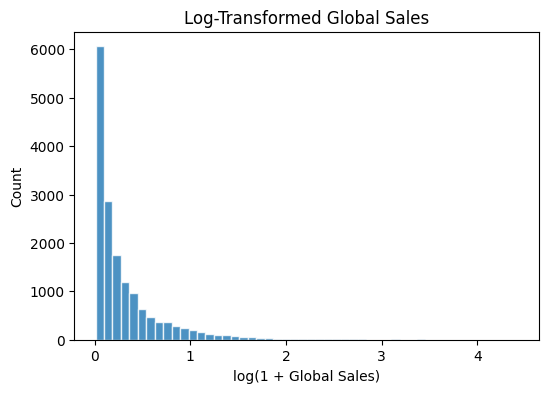

In [8]:
# Log-transformed global sales (from EDA: right-skewed raw distribution)
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(df_model["Global_Sales"]), bins=50, edgecolor="white", alpha=0.8)
plt.title("Log-Transformed Global Sales")
plt.xlabel("log(1 + Global Sales)")
plt.ylabel("Count")
plt.show()

### EDA 1: Distribution of the Top25 label

The target distribution shows that approximately one quarter of games fall into the top 25% of sales within their release year, while the remaining three quarters do not. This class imbalance reflects the natural skew of commercial success in the video game industry, where only a minority of titles achieve strong performance.

We define the positive class as the top 25% rather than a more extreme threshold (such as the top 10%) to maintain a balance between practical relevance and statistical stability. A rarer definition of success would reduce the number of positive examples, making model training less reliable and evaluation metrics more sensitive to noise. This choice ensures that the classification task remains meaningful while still capturing a distinct notion of high-performing games.

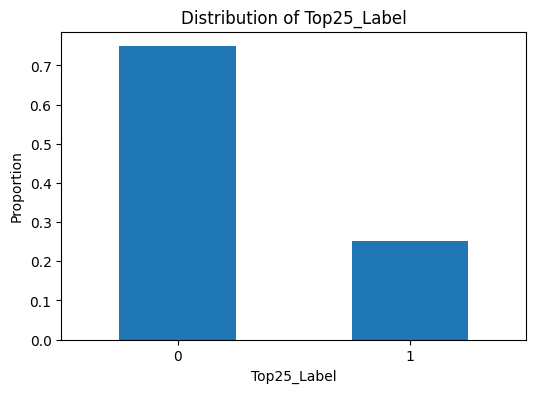

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
summary["proportion"].plot(kind="bar")
plt.title("Distribution of Top25_Label")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

### EDA 2: Genre-level Top25 success rates

The genre-level success-rate plot suggests that the probability of reaching the top quartile varies across genres. This indicates that genre is not merely a descriptive label but may contain information about expected audience demand and market fit. These differences are consistent with the idea that certain genres are systematically better aligned with player preferences or market conditions, and therefore have a higher likelihood of producing commercially successful titles. Even if genre alone is not sufficient for prediction, the observed variation across categories supports its inclusion as a useful pre-release feature and provides empirical support for our hypothesis that structural metadata contain meaningful predictive signal.

One could extend the analysis with **interaction terms** (e.g. genre × year) so that the effect of genre is allowed to vary by release year—similar to time-varying or year-fixed effects in panel data. That would be done in the **logistic regression** model (e.g. by adding Year×Genre or other interaction features before one-hot encoding); tree-based and boosting models (Random Forest, CatBoost) already capture such interactions implicitly, so we keep the main specification simple for all models. Importantly, this modeling choice reflects a trade-off between interpretability and flexibility: while explicit interaction terms may improve linear models, nonlinear models can capture these patterns without additional feature engineering.

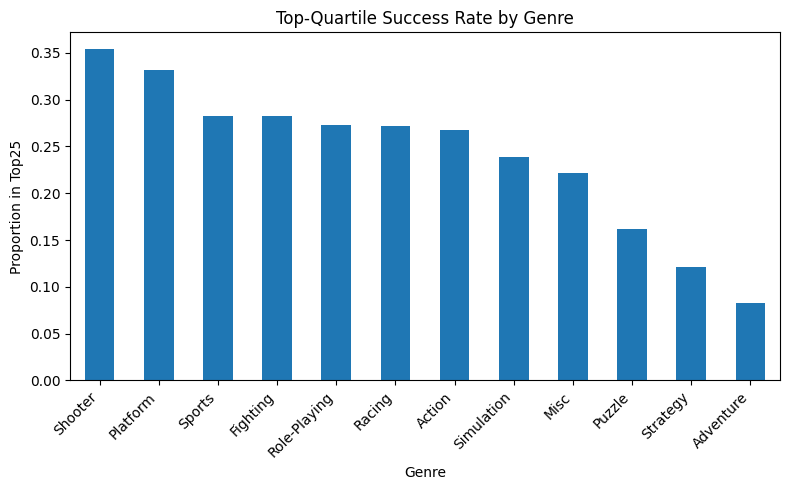

In [10]:
genre_dist = pd.crosstab(
    df_model["Genre"],
    df_model["Top25_Label"],
    normalize="index"
)

plt.figure(figsize=(8,5))
(genre_dist[1]).sort_values(ascending=False).plot(kind="bar")
plt.title("Top-Quartile Success Rate by Genre")
plt.ylabel("Proportion in Top25")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### EDA 3: Publisher-level Top25 success rates

Publisher-level differences show even stronger variation in top-quartile success rates, indicating that publisher identity is a particularly informative feature for prediction. Some publishers consistently achieve higher success rates, which likely reflects underlying factors such as brand reputation, marketing resources, franchise portfolios, and distribution capabilities. This pattern suggests that publisher is not merely a categorical identifier but a proxy for persistent structural advantages within the industry. The strength of this signal also helps explain why publisher-related features emerge as important in the predictive models. However, it is important to interpret this relationship as correlational rather than causal, as publisher identity may be associated with unobserved factors that directly drive commercial success.

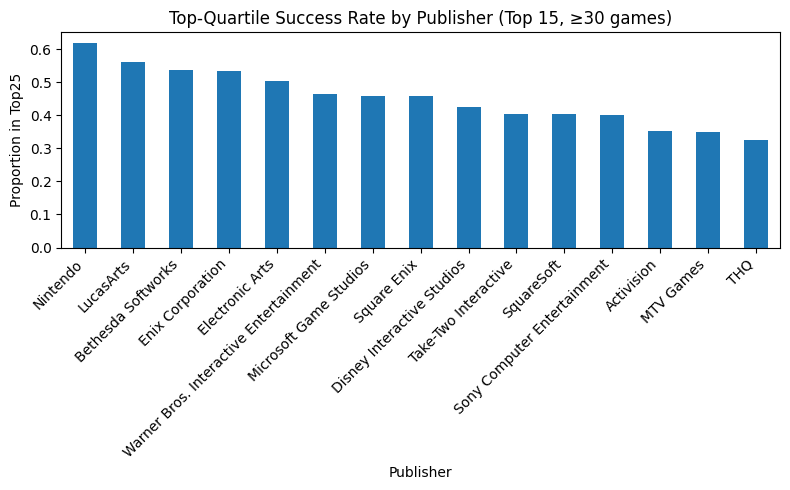

In [11]:
publisher_dist = pd.crosstab(
    df_model["Publisher"],
    df_model["Top25_Label"],
    normalize="index"
)

# Restrict to publishers with at least 30 games so success rates are comparable
min_games = 30
counts = df_model.groupby("Publisher").size()
publishers_enough = counts[counts >= min_games].index
publisher_sub = publisher_dist.loc[publisher_dist.index.isin(publishers_enough)]
publisher_top = (publisher_sub[1].sort_values(ascending=False)).head(15)

plt.figure(figsize=(8,5))
publisher_top.plot(kind="bar")
plt.title("Top-Quartile Success Rate by Publisher (Top 15, ≥" + str(min_games) + " games)")
plt.ylabel("Proportion in Top25")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### EDA 4: Releases over time

The number of game releases varies substantially across years, reflecting changes in the size and structure of the video game market over time. In particular, periods of rapid growth and subsequent decline highlight how the industry evolves in response to technological shifts, platform cycles, and market saturation. This temporal variation reinforces the importance of defining success relative to each release-year cohort rather than using raw sales values. It also suggests that release year may carry predictive information by capturing broader historical context, such as changes in competition intensity and market conditions. As a result, year is not only a control variable but also a meaningful feature that encodes time-dependent structure in the data.

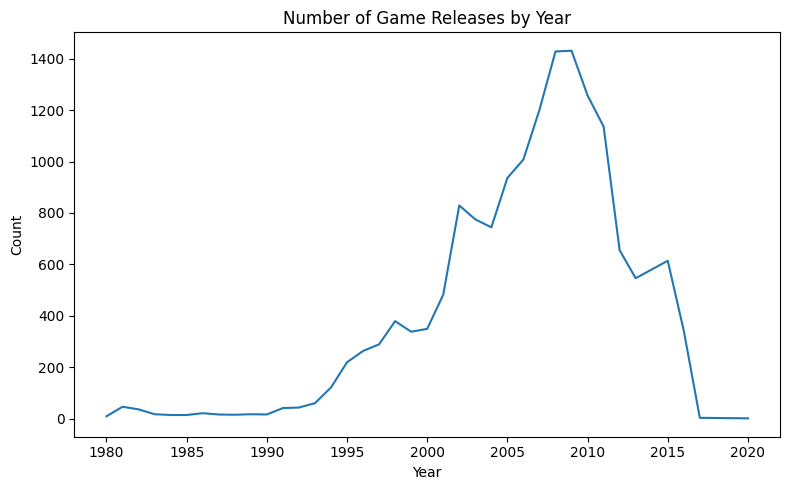

In [12]:
releases_per_year = df_model["Year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
releases_per_year.plot()
plt.title("Number of Game Releases by Year")
plt.ylabel("Count")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

### Baseline Model: Logistic Regression

We first fit a logistic regression model as an interpretable baseline. This model allows us to test whether a relatively simple linear decision boundary, applied to one-hot encoded metadata, can already distinguish games that reach the top quartile of release-year sales from those that do not.

Categorical predictors were one-hot encoded, and very infrequent publishers were grouped into an `Other` category using the training data only. We then evaluated the model on a held-out test set consisting of games released in 2015-2016 using accuracy, precision, recall, F1, and ROC-AUC so that model quality would not be judged by accuracy alone.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
from catboost import CatBoostClassifier

# Restrict to the main analysis window
analysis = df_model[(df_model["Year"] >= 1995) & (df_model["Year"] <= 2016)].copy()

# Temporal split: train on 1995-2014, test on 2015-2016
train_df = analysis[analysis["Year"] <= 2014].copy()
test_df  = analysis[analysis["Year"] >= 2015].copy()

# Collapse rare publishers using training data only
publisher_counts = train_df["Publisher"].value_counts()
rare_publishers  = publisher_counts[publisher_counts < 20].index

train_df["Publisher_Model"] = train_df["Publisher"].replace(rare_publishers, "Other")
test_df["Publisher_Model"]  = test_df["Publisher"].where(
    test_df["Publisher"].isin(publisher_counts.index.difference(rare_publishers)),
    "Other"
)

X_train = train_df[["Year", "Platform", "Genre", "Publisher_Model"]]
y_train = train_df["Top25_Label"]
X_test  = test_df[["Year", "Platform", "Genre", "Publisher_Model"]]
y_test  = test_df["Top25_Label"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Platform", "Genre", "Publisher_Model"]),
        ("num", "passthrough", ["Year"]),
    ]
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())

Train size: (14845, 4)  Test size: (956, 4)
Train positive rate: 0.25038733580330075  Test positive rate: 0.2510460251046025


### Baseline: Most-frequent classifier

As a sanity check, we first fit a dummy classifier that always predicts the majority class (not top quartile). This baseline shows how much performance can be achieved by exploiting class imbalance alone.

In [14]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy baseline")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy, zero_division=0))
print("F1:", f1_score(y_test, y_pred_dummy, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dummy))

Dummy baseline
Accuracy: 0.7489539748953975
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion matrix:
 [[716   0]
 [240   0]]


### Baseline Model: Logistic Regression

We next fit a logistic regression model as an interpretable baseline. This tests whether a relatively simple linear decision boundary on one-hot encoded metadata already contains predictive signal.

In [15]:
logit = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42)),
])

logit.fit(X_train, y_train)
y_pred_logit = logit.predict(X_test)
y_prob_logit = logit.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print("Precision:", precision_score(y_test, y_pred_logit, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_logit, zero_division=0))
print("F1:", f1_score(y_test, y_pred_logit, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logit))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_logit))
print("Classification report:\n", classification_report(y_test, y_pred_logit, digits=4, zero_division=0))

Logistic Regression
Accuracy: 0.8002092050209205
Precision: 0.6129032258064516
Recall: 0.5541666666666667
F1: 0.5820568927789934
ROC-AUC: 0.8318086592178772
Confusion matrix:
 [[632  84]
 [107 133]]
Classification report:
               precision    recall  f1-score   support

           0     0.8552    0.8827    0.8687       716
           1     0.6129    0.5542    0.5821       240

    accuracy                         0.8002       956
   macro avg     0.7341    0.7184    0.7254       956
weighted avg     0.7944    0.8002    0.7968       956



### Logistic regression with Year×Genre interaction

We add **Year×Genre** interaction terms so that the effect of genre can vary by release year (e.g. whether a genre is associated with top-quartile success may differ across years). This is done only for the logistic regression; tree-based models already capture such interactions implicitly. Below we fit a second logistic regression on the same train/test split with the interaction features and compare metrics.

In [25]:
# Build design matrix with Year × Genre interaction (same train/test split)
import numpy as np
X_base_train = preprocessor.transform(X_train)
X_base_test = preprocessor.transform(X_test)
# Convert to dense if sparse (OneHotEncoder often outputs sparse)
if hasattr(X_base_train, "toarray"):
    X_base_train = X_base_train.toarray()
    X_base_test = X_base_test.toarray()
X_base_train = np.asarray(X_base_train)
X_base_test = np.asarray(X_base_test)
feat_names = preprocessor.get_feature_names_out()
# OneHotEncoder order: Platform, Genre, Publisher_Model — find Genre columns
genre_ix = [i for i, n in enumerate(feat_names) if "Genre" in n]
year_ix = len(feat_names) - 1  # Year is last (passthrough in ColumnTransformer)
year_train = X_base_train[:, year_ix].reshape(-1, 1)
year_test = X_base_test[:, year_ix].reshape(-1, 1)
# Element-wise: (n,1) * (n,n_genre) -> (n,n_genre)
year_genre_train = year_train * X_base_train[:, genre_ix]
year_genre_test = year_test * X_base_test[:, genre_ix]
X_train_int = np.hstack([X_base_train, year_genre_train])
X_test_int = np.hstack([X_base_test, year_genre_test])

# Scale so Year and Year×Genre are on a similar scale to one-hot (helps convergence)
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
import warnings
scaler_int = StandardScaler()
X_train_int_scaled = scaler_int.fit_transform(X_train_int)
X_test_int_scaled = scaler_int.transform(X_test_int)

logit_int = LogisticRegression(max_iter=20000, random_state=42)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    logit_int.fit(X_train_int_scaled, y_train)
y_pred_int = logit_int.predict(X_test_int_scaled)
y_prob_int = logit_int.predict_proba(X_test_int_scaled)[:, 1]

print("Logistic Regression (with Year×Genre interaction)")
print("Accuracy:", accuracy_score(y_test, y_pred_int))
print("Precision:", precision_score(y_test, y_pred_int, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_int, zero_division=0))
print("F1:", f1_score(y_test, y_pred_int, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_int))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_int))
print("\nComparison: baseline logit ROC-AUC = {:.4f}, logit+interaction ROC-AUC = {:.4f}".format(
    roc_auc_score(y_test, y_prob_logit), roc_auc_score(y_test, y_prob_int)))

Logistic Regression (with Year×Genre interaction)
Accuracy: 0.7949790794979079
Precision: 0.6111111111111112
Recall: 0.5041666666666667
F1: 0.5525114155251142
ROC-AUC: 0.8347794459962756
Confusion matrix:
 [[639  77]
 [119 121]]

Comparison: baseline logit ROC-AUC = 0.8318, logit+interaction ROC-AUC = 0.8348


In this run, the logistic regression with Year×Genre interaction did not improve ROC-AUC over the baseline (and may be slightly lower). This is consistent with keeping the main specification simple: tree-based and boosting models below already capture such interactions implicitly, and the added interaction terms do not yield a clear gain for the linear model. We therefore report the baseline logistic regression as the interpretable linear baseline and do not include interaction terms in the main model comparison.

### Nonlinear Model: Random Forest

As a first nonlinear comparison, we fit a random forest classifier, which can capture interactions and nonlinear relationships among predictors.

In [18]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification report:\n", classification_report(y_test, y_pred_rf, digits=4, zero_division=0))

Random Forest
Accuracy: 0.8075313807531381
Precision: 0.6555555555555556
Recall: 0.49166666666666664
F1: 0.5619047619047619
ROC-AUC: 0.8280435288640596
Confusion matrix:
 [[654  62]
 [122 118]]
Classification report:
               precision    recall  f1-score   support

           0     0.8428    0.9134    0.8767       716
           1     0.6556    0.4917    0.5619       240

    accuracy                         0.8075       956
   macro avg     0.7492    0.7025    0.7193       956
weighted avg     0.7958    0.8075    0.7977       956



### Main Model: CatBoost

Finally, we fit a CatBoost classifier, a gradient boosting method designed for categorical data such as platform, genre, and publisher.

In [20]:
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    random_seed=42,
    verbose=False
)

cat_features = ["Platform", "Genre", "Publisher_Model"]

cat.fit(X_train, y_train, cat_features=cat_features)
probs_cat = cat.predict_proba(X_test)[:, 1]

# Use t = 0.4 as a balanced operating point
t = 0.4
y_pred_cat = (probs_cat >= t).astype(int)

print(f"CatBoost (threshold={t})")
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_cat, zero_division=0))
print("F1:", f1_score(y_test, y_pred_cat, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, probs_cat))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("Classification report:\n", classification_report(y_test, y_pred_cat, digits=4, zero_division=0))

CatBoost (threshold=0.4)
Accuracy: 0.801255230125523
Precision: 0.5984251968503937
Recall: 0.6333333333333333
F1: 0.6153846153846154
ROC-AUC: 0.8415677374301676
Confusion matrix:
 [[614 102]
 [ 88 152]]
Classification report:
               precision    recall  f1-score   support

           0     0.8746    0.8575    0.8660       716
           1     0.5984    0.6333    0.6154       240

    accuracy                         0.8013       956
   macro avg     0.7365    0.7454    0.7407       956
weighted avg     0.8053    0.8013    0.8031       956



#### Threshold analysis for CatBoost

We can move the decision threshold to trade precision against recall. The table below summarizes CatBoost performance for several thresholds (0.3, 0.4, 0.5, 0.6). For our main results we report the balanced setting at 0.4, but other operating points may be appropriate depending on whether one cares more about catching as many potential hits as possible or avoiding false alarms.

#### Cross-validated assessment of CatBoost (5-fold)

As a complementary assessment, we also evaluate CatBoost using stratified 5-fold cross-validation on games released between 1995 and 2016. This ignores time ordering and uses random splits across years. In our run, the mean CV ROC-AUC (around 0.80) is somewhat lower than the temporal 2015–2016 test ROC-AUC (around 0.85). That is plausible: the temporal test set (2015–2016) is chronologically adjacent to the training window, so the model may generalize better to those years than to a random mix of years in each CV fold. The CV still shows that CatBoost performs well across folds and supports that our main conclusion (CatBoost as the strongest model) is not driven by a single lucky split.

In [21]:
from sklearn.model_selection import StratifiedKFold

# Prepare full analysis window, with the same publisher collapse strategy
analysis_cv = df_model[(df_model["Year"] >= 1995) & (df_model["Year"] <= 2016)].copy()

publisher_counts_cv = analysis_cv["Publisher"].value_counts()
rare_publishers_cv = publisher_counts_cv[publisher_counts_cv < 20].index
analysis_cv["Publisher_Model"] = analysis_cv["Publisher"].replace(rare_publishers_cv, "Other")

X_cv = analysis_cv[["Year", "Platform", "Genre", "Publisher_Model"]]
y_cv = analysis_cv["Top25_Label"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    X_tr, X_te = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_tr, y_te = y_cv.iloc[train_idx], y_cv.iloc[test_idx]

    cat_cv = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=1500,
        depth=8,
        learning_rate=0.05,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=False,
    )

    cat_cv.fit(X_tr, y_tr, cat_features=["Platform", "Genre", "Publisher_Model"])
    probs_cv = cat_cv.predict_proba(X_te)[:, 1]

    # Use the same threshold t = 0.4
    t_cv = 0.4
    y_pred_cv = (probs_cv >= t_cv).astype(int)

    cv_rows.append({
        "fold": fold,
        "accuracy": accuracy_score(y_te, y_pred_cv),
        "precision": precision_score(y_te, y_pred_cv, zero_division=0),
        "recall": recall_score(y_te, y_pred_cv, zero_division=0),
        "f1": f1_score(y_te, y_pred_cv, zero_division=0),
        "roc_auc": roc_auc_score(y_te, probs_cv),
    })

cv_results = pd.DataFrame(cv_rows)
print(cv_results)
print("\nMean across folds:\n", cv_results.mean(numeric_only=True))

   fold  accuracy  precision    recall        f1   roc_auc
0     1  0.783929   0.575800  0.522727  0.547981  0.802701
1     2  0.791456   0.588079  0.560606  0.574014  0.814572
2     3  0.786392   0.576720  0.551201  0.563672  0.807523
3     4  0.769304   0.541005  0.517067  0.528765  0.791193
4     5  0.775633   0.553109  0.539823  0.546385  0.807920

Mean across folds:
 fold         3.000000
accuracy     0.781343
precision    0.566943
recall       0.538285
f1           0.552164
roc_auc      0.804782
dtype: float64


### ROC curves for all models

To visualize overall ranking performance across different thresholds, we plot ROC curves for the three learned models (Logistic Regression, Random Forest, CatBoost). The dummy classifier is shown as a near-diagonal reference line.

/Users/yidongli/Desktop/李奕东/UCSD/课程/COGS/COGS 108/Data Project/Group140_WI26/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


<Figure size 700x500 with 0 Axes>

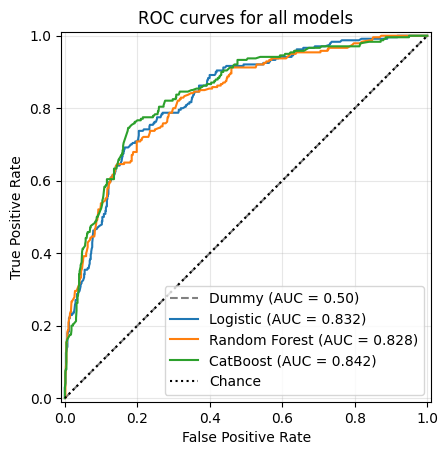

In [22]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Dummy: use constant scores equal to the predicted class (always 0)
y_score_dummy = y_pred_dummy  # all zeros
disp_dummy = RocCurveDisplay.from_predictions(
    y_test, y_score_dummy, name="Dummy", linestyle="--", color="gray"
)

# Logistic
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
plt.plot(fpr_logit, tpr_logit, label="Logistic (AUC = {:.3f})".format(roc_auc_score(y_test, y_prob_logit)))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.3f})".format(roc_auc_score(y_test, y_prob_rf)))

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, probs_cat)
plt.plot(fpr_cat, tpr_cat, label="CatBoost (AUC = {:.3f})".format(roc_auc_score(y_test, probs_cat)))

plt.plot([0, 1], [0, 1], "k:", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves for all models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Precision–Recall curve for CatBoost

Because the positive class (Top25 games) is a minority, the precision–recall curve is especially informative. It shows how precision falls as we push recall higher by lowering the decision threshold.

<Figure size 600x400 with 0 Axes>

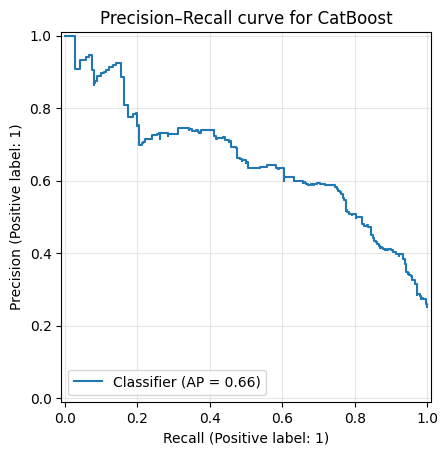

In [23]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, probs_cat)
plt.title("Precision–Recall curve for CatBoost")
plt.grid(alpha=0.3)
plt.show()

### Feature importance for Random Forest

To understand which metadata fields drive the Random Forest predictions, we plot the top features from the one-hot encoded representation. These reflect both the overall importance of year and the contribution of specific platforms, genres, and publisher groups.

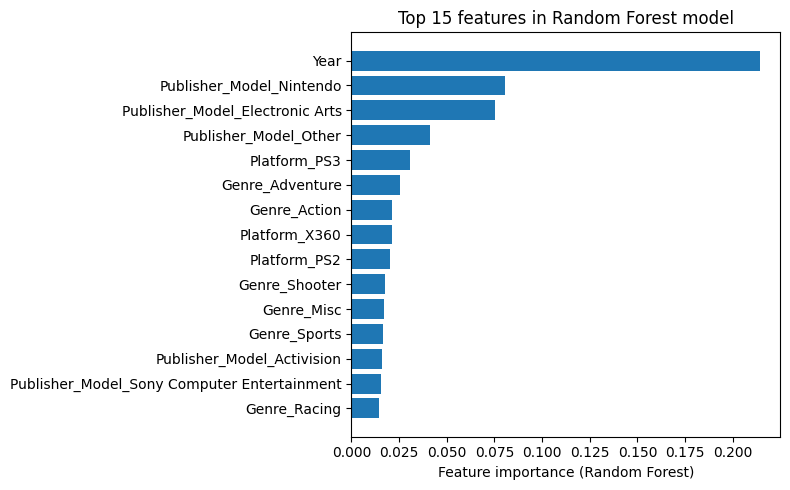

In [24]:
# Extract feature importances from the trained Random Forest pipeline
rf_clf = rf.named_steps["classifier"]
ohe = rf.named_steps["preprocessor"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(["Platform", "Genre", "Publisher_Model"]).tolist()
all_feature_names = cat_feature_names + ["Year"]

importances = rf_clf.feature_importances_

# Put into a DataFrame for convenience
import pandas as pd
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
imp_top = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(imp_top["feature"][::-1], imp_top["importance"][::-1])
plt.xlabel("Feature importance (Random Forest)")
plt.title("Top 15 features in Random Forest model")
plt.tight_layout()
plt.show()

### Genre-level performance for CatBoost (optional subgroup check)

As a simple subgroup analysis, we can examine how well the CatBoost model performs across different genres by looking at F1 scores within each genre. This helps illustrate that even our best model performs better on some types of games than others.

#### Model assessment summary

We primarily evaluate our models using a temporal split that trains on games released from 1995 to 2014 and tests on games released in 2015–2016, which mimics a realistic "predict future titles from past data" scenario. As a robustness check, we also run stratified 5-fold cross-validation over the 1995–2016 window for CatBoost. The mean CV performance is somewhat lower than the 2015–2016 temporal test (e.g. mean CV ROC-AUC ~0.80 vs. temporal ~0.85), which is plausible because the temporal test set is chronologically adjacent to the training period. In both settings CatBoost remains the strongest model, and the relative ranking (Dummy < Logistic Regression ≈ Random Forest < CatBoost) is stable. This combination of temporal evaluation, cross-validated performance, and error/feature analysis suggests that our conclusions about model performance are not an artifact of a particular train/test split.

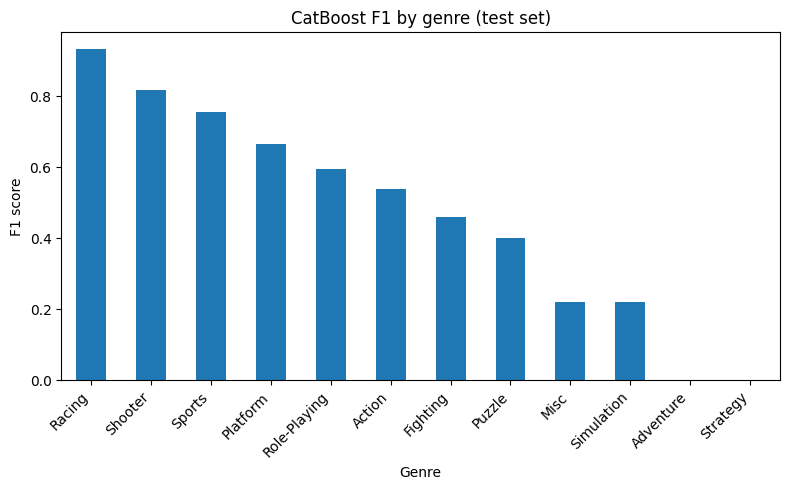

In [ ]:
# Merge predictions back to the test DataFrame
cat_results = test_df.copy()
cat_results["y_true"] = y_test.values
cat_results["y_pred_cat"] = y_pred_cat

# Compute F1 by genre
from sklearn.metrics import f1_score

genre_f1 = (
    cat_results
    .groupby("Genre")
    .apply(lambda g: f1_score(g["y_true"], g["y_pred_cat"], zero_division=0))
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
genre_f1.plot(kind="bar")
plt.ylabel("F1 score")
plt.title("CatBoost F1 by genre (test set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6]
rows = []
for t in thresholds:
    y_pred_t = (probs_cat >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

import pandas as pd
pd.DataFrame(rows)

,threshold,accuracy,precision,recall,f1
0,0.3,0.802301,0.582524,0.750000,0.655738
1,0.4,0.801255,0.598425,0.633333,0.615385
2,0.5,0.812762,0.639269,0.583333,0.610022
3,0.6,0.808577,0.661017,0.487500,0.561151


### Model Comparison and Error Analysis

The model comparison reveals a nuanced pattern rather than a simple one-model-wins story. The dummy classifier achieves reasonably high accuracy by always predicting the majority class, but it has zero precision, recall, and F1 for the positive class, confirming that accuracy alone is not an appropriate metric under class imbalance. Logistic regression substantially improves on this baseline and provides a strong balance of recall, F1, and ROC-AUC, suggesting that a relatively simple linear model is already able to capture meaningful structure in the pre-release metadata. Random forest achieves slightly higher accuracy and precision but lower recall and F1, acting as a more conservative classifier that prioritizes avoiding false positives at the cost of missing some successful games. CatBoost delivers the best overall trade-off, with the highest F1 and ROC-AUC among the three learned models, indicating that it is more effective at capturing nonlinear relationships and interactions among features.

The confusion matrices further illustrate how these models differ in their prediction behavior. All models identify a meaningful share of top-quartile games, but they make different trade-offs between false positives and false negatives. Logistic regression produces more true positives than random forest, which helps explain its stronger recall and F1. Random forest produces fewer false positives, consistent with its stronger precision. CatBoost achieves the highest number of true positives while keeping the number of false positives moderate, aligning with its stronger balanced performance. From a practical perspective, this suggests that CatBoost is the most suitable model when the goal is to identify as many high-performing games as possible without introducing excessive false alarms, while logistic regression remains a strong and interpretable baseline.

## Ethics


### A. Data Collection
 - [ ] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
This project relies exclusively on publicly available datasets (e.g., Kaggle’s Video Game Sales and the RAWG Video Games Dataset). No personal data from human subjects are collected, so informed consent is not required.
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
We recognize that these datasets may favor well-known or commercially successful games, while independent or niche titles may be underrepresented. This limitation will be noted, and multiple public sources will be combined where possible to reduce bias.
 - [ ] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
The datasets contain no personally identifiable information (PII), such as player names or account details. All analysis is limited to game-level attributes (e.g., genre, platform, publisher) and sales figures.
 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
Because no player demographic data are included, bias analysis across protected groups is not applicable. However, we will avoid reinforcing stereotypes related to genre or region and will discuss dataset representativeness in the report.

This project uses only publicly available datasets (Kaggle's Video Game Sales and RAWG). No personal data are collected, so informed consent is not required. We acknowledge that these datasets may overrepresent commercially successful games while underrepresenting independent or niche titles—a limitation we will note in the report. The datasets contain no personally identifiable information (PII); all analysis is limited to game-level attributes (genre, platform, publisher) and sales figures. Because no player demographic data are included, bias analysis across protected groups is not applicable, but we will avoid reinforcing stereotypes related to gender or region.

### B. Data Storage
 - [ ] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
Data will be stored locally on team members’ personal computers and accessed only by the project team. Files will be kept in password-protected or encrypted folders and will not be uploaded to public cloud storage.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
Data will be retained only for the duration of the course project (Fall 2025). After completion, all raw and processed data will be deleted, with only the final report and aggregated results preserved.

Data will be stored locally on team members' personal computers, accessed only by the project team, and kept in password-protected or encrypted folders. No data will be uploaded to public cloud storage. The right to be forgotten is not applicable as no personal data are collected. Data will be retained only through Spring 2026; after project completion, all raw and processed data will be deleted, preserving only the final report and aggregated results.


### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
To reduce analytical blind spots, we will reference industry reports, relevant academic research, and insights from peers with experience in the gaming industry.
 - [ ] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
We will assess potential biases such as class imbalance across genres and temporal skew toward recent releases and account for these issues during analysis and modeling.
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
Visualizations and summaries will use appropriate scales and labels. Both significant and non-significant results will be reported, along with uncertainty where relevant.
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
All data processing and analysis code will be documented and version-controlled on GitHub to ensure reproducibility.

To address analytical blind spots, we will reference industry reports, academic research, and insights from gaming industry peers. We will assess potential biases such as class imbalance across genres and temporal skew toward recent releases, accounting for these issues during analysis and modeling. Visualizations will use appropriate scales and labels, reporting both significant and non-significant results with uncertainty where relevant. All code will be documented and version-controlled on GitHub to ensure reproducibility.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
​​Fairness considerations will focus on model performance differences across game genres and platforms, as no player demographic data are available.
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
Model evaluation will consider accuracy, precision, recall, and F1 score, with metrics chosen based on the project’s analytical goals.
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
We will favor interpretable models (e.g., logistic regression, decision trees) and use feature importance and related methods to explain model behavior.
 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

The report will clearly state that predictions are shaped by historical data biases and should not be interpreted as objective measures of game quality or cultural value.

The model does not rely on discriminatory variables, as no demographic data are included. Fairness considerations will focus on performance differences across game genres and platforms. Model evaluation will consider accuracy, precision, recall, and F1 score. We will favor interpretable models (e.g., logistic regression) and use feature importance to explain model behavior. The report will clearly state that predictions are shaped by historical data biases and should not be interpreted as objective measures of game quality or cultural value.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
We explicitly state that this model is for academic exploration only and should not be used as the sole basis for commercial decisions or for labeling games or players.

This model is for academic exploration only and will not be deployed. We explicitly state that it should not be used as the sole basis for commercial decisions or for labeling games or players.

No additional updates from proposal feedback were required for this submission.


## Discussion and Conclusion

Our project asked whether pre-release metadata can predict whether a video game will rank in the top 25% of global sales within its release year. By redefining success in relative rather than absolute terms, we aimed to make outcomes more comparable across years and better aligned with a practical pre-release prediction setting.

The results suggest that the answer is yes, but only to a limited extent. Logistic regression, random forest, and CatBoost all extracted meaningful predictive signal from release year, platform, genre, and publisher. Among these models, CatBoost achieved the strongest overall performance in terms of F1 score and ROC-AUC, indicating that nonlinear relationships and interactions among features are important for this task. Logistic regression provided a strong and interpretable baseline, while random forest achieved higher precision at the cost of lower recall, illustrating different trade-offs between identifying successful games and avoiding false positives. Taken together, these findings suggest that pre-release structural metadata do contain useful information about a game’s likelihood of becoming a relatively strong commercial performer within its release-year cohort.

At the same time, the models are far from perfect, which is itself an important result. Commercial success in video games is shaped by many factors that are not included in our dataset, such as marketing budgets, franchise recognition, pricing, release timing, game quality, and post-release review dynamics. The fact that our models can only partially predict top-quartile success highlights that structured metadata alone capture only one component of a much more complex commercial process.

Our exploratory analyses and model interpretation further suggest that publisher, platform, genre, and release year all contribute to prediction, though not equally. Publisher-related features appear especially informative, and `Year` emerges as a dominant predictor in tree-based and boosting models. This is consistent with the idea that release timing, publisher identity, and platform environment encode broader historical and structural patterns in the video game market. However, these variables should be interpreted as predictive signals rather than causal determinants of success.

This study has several limitations. The dataset may not fully represent all segments of the video game market, especially smaller or less well-documented titles. In addition, `Global_Sales` measure unit volume rather than revenue or profitability, which may bias the definition of success. Multiple platform versions of the same game are treated as separate observations, and many important pre-release and post-release factors remain unobserved. Furthermore, some years in the raw dataset are sparse, which motivated our restriction of the main analysis window to 1995–2016 and evaluation on 2015–2016.

Overall, our findings show that simple metadata-based models can serve as useful early-stage screening tools for identifying potentially strong-performing games, but they cannot provide a complete or definitive account of video game success. Future work could extend this framework by incorporating richer pre-release information, such as marketing exposure or franchise history, as well as post-release signals like review scores and player engagement. Exploring alternative definitions of success, such as revenue-based measures, and examining fairness across different types of games (e.g., indie versus AAA titles) would also provide a more comprehensive understanding of how predictive models interact with existing market structures.